# Supply Chain Performance Analytics

This notebook contains the Exploratory Data Analysis (EDA) and Business KPI reporting for a 100-SKU supply chain dataset. 
The analysis is structured in five phases:
- **Phase 1: Load & Clean**
- **Phase 2: Feature Engineering**
- **Phase 3: EDA & KPIs**
- **Phase 4: Visualizations**
- **Phase 5: Insights & Deliverables**

## Phase 0: Working Assumptions & Data Dictionary

Given the lack of official documentation, we establish the following working assumptions:
1. **Lead Time Columns**:
   - `lead_times`: Supplier-to-warehouse delivery lead time (in days).
   - `lead_time`: End-to-end customer order-to-delivery fulfillment lead time (in days).
   - `manufacturing_lead_time`: Supplier production lead time (in days).
2. **Cost Columns**:
   - `manufacturing_costs`: Unit-level direct manufacturing cost.
   - `shipping_costs`: Unit-level transport cost.
   - `costs`: Route-level logistics freight cost (transaction/lane cost, not unit-level).
3. **Data Limitations**:
   - No product-name column (analysis conducted at SKU level).
   - No temporal column (no time-series trends possible).

## Phase 1: Load & Clean

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = r'data/supply_chain_data.csv'

# Load data
print(f"Loading data from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

# Check shape and duplicates
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Duplicate Rows: {df.duplicated().sum()}")

# Check nulls
print("\nNull count per column:")
print(df.isnull().sum())

# Standardize columns
original_cols = list(df.columns)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("\nColumns standardized to snake_case.")

df.head(3)

Loading data from: data/supply_chain_data.csv
Shape: 100 rows, 24 columns
Duplicate Rows: 0

Null count per column:
Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

Columns standardized to snake_case.


,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,...,location,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282


## Phase 2: Feature Engineering

In [2]:
# Create copy
df_feat = df.copy()

# 1. Realized price per unit
df_feat['revenue_per_unit'] = df_feat['revenue_generated'] / df_feat['number_of_products_sold']

# 2. Gross Unit Profit (listed price)
df_feat['gross_unit_profit'] = df_feat['price'] - df_feat['manufacturing_costs']

# 3. Gross Profit Margin (%)
df_feat['gross_profit_margin_pct'] = df_feat['gross_unit_profit'] / df_feat['price']

# 4. Net Unit Profit (including unit shipping)
df_feat['net_unit_profit'] = df_feat['price'] - df_feat['manufacturing_costs'] - df_feat['shipping_costs']

# 5. Net Profit Margin (%)
df_feat['net_profit_margin_pct'] = df_feat['net_unit_profit'] / df_feat['price']

# 6. Total Mfg Cost
df_feat['total_manufacturing_cost'] = df_feat['manufacturing_costs'] * df_feat['production_volumes']

# 7. Stock-to-Sales Ratio
df_feat['stock_to_sales_ratio'] = df_feat['stock_levels'] / df_feat['number_of_products_sold']

# 8. Late Delivery Flag
df_feat['is_late_delivery'] = (df_feat['shipping_times'] > 7).astype(int)

print("Engineered Features Summary:")
print(df_feat[['revenue_per_unit', 'gross_unit_profit', 'gross_profit_margin_pct', 'net_unit_profit', 'net_profit_margin_pct', 'stock_to_sales_ratio', 'is_late_delivery']].describe())

# Discrepancy Checks
neg_gross = df_feat[df_feat['gross_unit_profit'] < 0]
print(f"\nSKUs with manufacturing cost exceeding list price: {len(neg_gross)} out of {len(df_feat)}")

Engineered Features Summary:
       revenue_per_unit  gross_unit_profit  gross_profit_margin_pct  \
count        100.000000         100.000000               100.000000   
mean          41.356314           2.195768                -2.132715   
std          128.153396          46.304576                 6.119104   
min            1.366235         -94.285616               -32.392516   
25%            7.788644         -31.569189                -1.277409   
50%           12.828546           7.059568                 0.199762   
75%           23.435046          34.951391                 0.620344   
max         1197.218703          93.379892                 0.970221   

       net_unit_profit  net_profit_margin_pct  stock_to_sales_ratio  \
count       100.000000             100.000000            100.000000   
mean         -3.352381              -2.474131              0.216744   
std          46.285930               6.666977              0.422485   
min         -97.210474             -35.006728  

## Phase 3: EDA & KPIs

In [3]:
print("--- 1. FINANCIAL KPIs ---")
total_rev = df_feat['revenue_generated'].sum()
total_mfg_sold = (df_feat['manufacturing_costs'] * df_feat['number_of_products_sold']).sum()
total_ship_sold = (df_feat['shipping_costs'] * df_feat['number_of_products_sold']).sum()
total_route_freight = df_feat['costs'].sum()
total_cost = total_mfg_sold + total_ship_sold + total_route_freight
net_profit = total_rev - total_cost
margin_pct = (net_profit / total_rev) * 100

print(f"Total Revenue: ${total_rev:,.2f}")
print(f"Total COGS (Manufacturing): ${total_mfg_sold:,.2f}")
print(f"Total Shipping Cost (Sold Units): ${total_ship_sold:,.2f}")
print(f"Total Route Freight Cost: ${total_route_freight:,.2f}")
print(f"Total Supply Chain Cost: ${total_cost:,.2f}")
print(f"Net Supply Chain Profit: ${net_profit:,.2f}")
print(f"Overall Profit Margin: {margin_pct:.2f}%")

print("\n--- 2. INVENTORY KPIs ---")
print(f"Average Stock Level: {df_feat['stock_levels'].mean():.2f} units")
print(f"Average Product Availability: {df_feat['availability'].mean():.2f}%")
print(f"Average Stock-to-Sales Ratio: {df_feat['stock_to_sales_ratio'].mean():.4f}")

print("\nInventory Metrics by Product Type:")
print(df_feat.groupby('product_type')[['stock_levels', 'availability', 'stock_to_sales_ratio']].mean())

print("\n--- 3. SUPPLIER PERFORMANCE ---")
print(df_feat.groupby('supplier_name').agg(
    avg_defect_rate=('defect_rates', 'mean'),
    avg_lead_times=('lead_times', 'mean'),
    total_production_volume=('production_volumes', 'sum'),
    sku_count=('sku', 'count')
))

print("\n--- 4. CARRIER & ROUTE PERFORMANCE ---")
carrier_stats = df_feat.groupby('shipping_carriers').agg(
    avg_shipping_cost=('shipping_costs', 'mean'),
    avg_shipping_time=('shipping_times', 'mean'),
    late_delivery_rate=('is_late_delivery', 'mean')
)
carrier_stats['late_delivery_rate'] *= 100
print(carrier_stats)

print("\nRoute & Mode Logistics Cost Analysis:")
print(df_feat.groupby(['routes', 'transportation_modes'])['costs'].mean().unstack())

print("\n--- 5. QUALITY CONTROL ANALYSIS ---")
print("Inspection Results Counts:")
print(df_feat['inspection_results'].value_counts())
print("\nAverage Defect Rate by Inspection Result:")
print(df_feat.groupby('inspection_results')['defect_rates'].mean())

print("\n--- 6. CORRELATION NOISE DETECTION ---")
numeric_corr = df_feat.select_dtypes(include='number').corr()
corr_pairs = numeric_corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print("Top Positive Correlations:")
print(corr_pairs.head(3))
print("\nTop Negative Correlations:")
print(corr_pairs.tail(3))
weak_corrs = corr_pairs[corr_pairs.abs() < 0.2]
print(f"\nStatistical Noise Flag: There are {len(weak_corrs)} correlation pairs with |r| < 0.2. With N=100, these are likely noise.")

--- 1. FINANCIAL KPIs ---
Total Revenue: $577,604.82
Total COGS (Manufacturing): $2,208,830.61
Total Shipping Cost (Sold Units): $259,295.35
Total Route Freight Cost: $52,924.58
Total Supply Chain Cost: $2,521,050.54
Net Supply Chain Profit: $-1,943,445.72
Overall Profit Margin: -336.47%

--- 2. INVENTORY KPIs ---
Average Stock Level: 47.77 units
Average Product Availability: 48.40%
Average Stock-to-Sales Ratio: 0.2167

Inventory Metrics by Product Type:
              stock_levels  availability  stock_to_sales_ratio
product_type                                                  
cosmetics        58.653846     51.230769              0.211247
haircare         48.352941     43.264706              0.325142
skincare         40.200000     50.925000              0.128180

--- 3. SUPPLIER PERFORMANCE ---
               avg_defect_rate  avg_lead_times  total_production_volume  \
supplier_name                                                             
Supplier 1            1.803630       16.777

## Phase 4: Visualizations

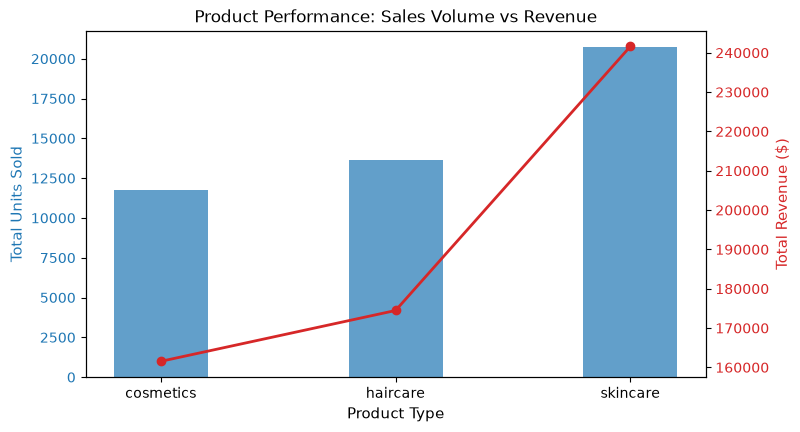

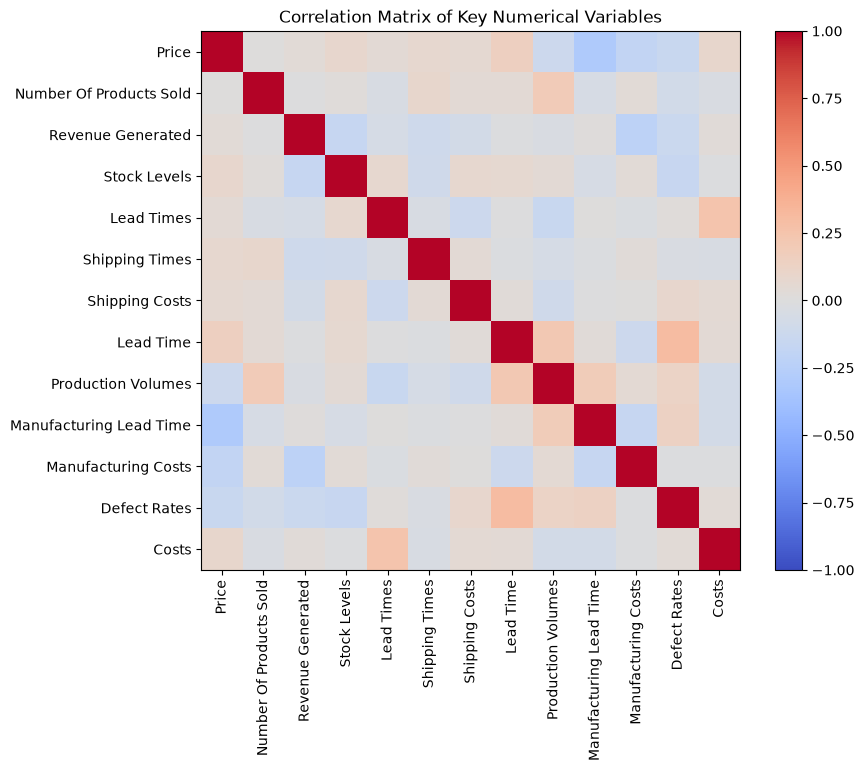

In [4]:
%matplotlib inline
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 12})

# Chart 1: Revenue vs Volume Sold
product_stats = df_feat.groupby('product_type').agg(
    total_sales=('number_of_products_sold', 'sum'),
    total_revenue=('revenue_generated', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(8, 4.5))
color = '#1f77b4'
ax1.set_xlabel('Product Type')
ax1.set_ylabel('Total Units Sold', color=color)
bars = ax1.bar(product_stats['product_type'], product_stats['total_sales'], color=color, alpha=0.7, width=0.4)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Total Revenue ($)', color=color)
line = ax2.plot(product_stats['product_type'], product_stats['total_revenue'], color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Product Performance: Sales Volume vs Revenue')
plt.show()

# Chart 2: Correlation Heatmap
cols_to_corr = ['price', 'number_of_products_sold', 'revenue_generated', 'stock_levels', 'lead_times', 'shipping_times', 'shipping_costs', 'lead_time', 'production_volumes', 'manufacturing_lead_time', 'manufacturing_costs', 'defect_rates', 'costs']
corr_matrix = df_feat[cols_to_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
cax = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(len(cols_to_corr))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels([c.replace('_', ' ').title() for c in cols_to_corr], rotation=90)
ax.set_yticklabels([c.replace('_', ' ').title() for c in cols_to_corr])
plt.title('Correlation Matrix of Key Numerical Variables')
plt.show()